# **US Accidents - Exploratory Data Analysis & Prediction**

## **Introduction**
Traffic accidents have always been one of the leading public safety issues in the United States as well as around the world. Understanding the factors that influence accidents (such as weather conditions, transportation infrastructure, and time of day) not only helps improve traffic planning but also supports authorities in implementing effective preventive measures.

This project focuses on Exploratory Data Analysis (EDA) and Data Preparation using a U.S. traffic accident dataset, with the aim of uncovering important insights and building a foundation for forecasting.

## **Dataset Description**
The dataset used in this project is **US Accidents (2020 - 2023)**, one of the most up-to-date and detailed nationwide traffic accident datasets.
* **Data source:** Kaggle Dataset
* **Scope:** Includes over 3 million accident records across 49 U.S. states.
* **Attributes:** The dataset contains detailed information such as:
    * **Severity:** A scale from 1 to 4 indicating the impact level of the accident.
    * **Time & Location:** Start/end times, latitude/longitude, street names, city, and state.
    * **Environmental conditions:** Temperature, humidity, visibility, wind speed, and weather conditions (rain, snow, fog, etc.).
    * **Infrastructure features:** Presence of traffic lights, signs, speed bumps, and more.

## **Project Objectives**
Based on the requirements of the **Data Preparation and Visualization** course, the main objectives are as follows:

1.  **Data Cleaning & Preprocessing:** Handle outlier data, missing values, and standardize data formats.
2.  **Exploratory Data Analysis (EDA):**
    * Analyze the distribution of all features.
    * Evaluate the impact of weather conditions and traffic infrastructure on accident severity.
    * Visualize the data to tell a story (Data Storytelling) about the traffic accidents in the U.S.
3.  **Feature Engineering & Selection:** Create useful new features.
4.  **Modeling Strategy:** Experiment with machine learning models (such as Random Forest, XGBoost, LightGBM, CatBoost) for prediction and performance evaluation.

## **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, f1_score, cohen_kappa_score, mean_squared_error
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## **Load Dataset**

In [2]:
df_train = pd.read_csv('dataset/raw/train.csv')
df_train.head()

,ID,Severity,Start_Time,End_Time,Latitude,Longitude,Distance(mi),Description,Street,City,...,Visibility(mi),Weather_Condition,Amenity,Crossing,Junction,Railway,Station,Stop,Traffic_Signal,Sunrise_Sunset
0,A-4081224,4,2022-03-18 06:55:00,2022-03-18 11:55:00,36.081864,-79.080223,0.039,The road is closed near St Mary's Rd.,St Marys Rd,Hillsborough,...,NaN,NaN,False,False,False,False,False,False,False,Night
1,A-4338502,2,2023-01-29 16:35:00,2023-01-29 17:53:04,38.927944,-121.056469,0.014,Incident on BOWMAN RD near LUTHER RD Drive wit...,Bowman Rd,Auburn,...,10.0,Cloudy,False,False,False,False,False,True,False,Day
2,A-4813526,2,2022-10-11 12:53:40,2022-10-11 14:44:43,37.539693,-77.432146,0.008,Incident on N 11TH ST near E BROAD ST RICH Dri...,E Broad St,Richmond,...,10.0,Fair,False,True,False,False,False,False,True,Day
3,A-4731406,2,2022-01-24 06:12:00,2022-01-24 06:40:30,36.998262,-76.409113,0.944,Slow traffic on I-664 S from Aberdeen Rd/Exit ...,I-664 S,Newport News,...,10.0,Fair,False,False,True,False,False,False,False,Night
4,A-7263275,2,2020-02-14 15:28:00,2020-02-14 16:26:09,38.524770,-121.467450,0.000,At Fruitridge Rd - Accident.,CA-99 N,Sacramento,...,10.0,Fair,False,False,True,False,False,False,False,Day


## **Data Understanding**
Perform the steps to explore and understand the structure of the initial dataset.

In [3]:
df_train.columns.tolist()

['ID',
 'Severity',
 'Start_Time',
 'End_Time',
 'Latitude',
 'Longitude',
 'Distance(mi)',
 'Description',
 'Street',
 'City',
 'County',
 'State',
 'Zipcode',
 'Timezone',
 'Airport_Code',
 'Weather_Timestamp',
 'Temperature(F)',
 'Humidity(%)',
 'Visibility(mi)',
 'Weather_Condition',
 'Amenity',
 'Crossing',
 'Junction',
 'Railway',
 'Station',
 'Stop',
 'Traffic_Signal',
 'Sunrise_Sunset']

## Explore the Columns and Data Types

In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2492196 entries, 0 to 2492195
Data columns (total 28 columns):
 #   Column             Dtype  
---  ------             -----  
 0   ID                 object 
 1   Severity           int64  
 2   Start_Time         object 
 3   End_Time           object 
 4   Latitude           float64
 5   Longitude          float64
 6   Distance(mi)       float64
 7   Description        object 
 8   Street             object 
 9   City               object 
 10  County             object 
 11  State              object 
 12  Zipcode            object 
 13  Timezone           object 
 14  Airport_Code       object 
 15  Weather_Timestamp  object 
 16  Temperature(F)     float64
 17  Humidity(%)        float64
 18  Visibility(mi)     float64
 19  Weather_Condition  object 
 20  Amenity            bool   
 21  Crossing           bool   
 22  Junction           bool   
 23  Railway            bool   
 24  Station            bool   
 25  Stop              

- The dataset has a size of 415.9+ MB.
- It contains 2,492,196 rows and 28 columns (includes 7 boolean variables, 7 numerical variables, and 14 categorical variables).

This is an important step for distinguishing variable types and preparing for further data classification.

# Dataset Dictionary

| Key               | Role    | Type                     | List (Range) of values                                   | Meaning explanation |
|-------------------|---------|--------------------------|-----------------------------------------------------------|---------------------|
| ID                | ID      | ID                       | A-3655686 ... A-5031810                                   | Unique identifier for each accident record. Used for data management. |
| Severity          | Target  | Categorical (Ordinal)    | 1 → 4                                                     | Severity level of the accident; higher = more severe. |
| Start_Time        | Feature | Date/Time                | 2016-01-15 ... 2023-04-01                                 | Exact time the accident started; used for time-based analysis. |
| End_Time          | Feature | Date/Time                | 2016-02-08 ... 2023-04-01                                 | Time when traffic returned to normal. Duration = congestion time. |
| Latitude          | Feature | Numerical (Continuous)   | 24.570087 → 49.009504                                     | Latitude of accident. |
| Longitude         | Feature | Numerical (Continuous)   | -124.541015 → -69.036659                                  | Longitude of accident. |
| Distance(mi)      | Feature | Numerical (Continuous)   | 0.0 → 112.903                                              | Length of road segment affected. |
| Description       | Feature | Text                     | Long text (~541103 values)                                | Detailed accident description. |
| Street            | Feature | Categorical              | 1 1/2 Ave ... Zuniga Dr (112,901 values)                 | Street where the accident occurred. |
| City              | Feature | Categorical              | Aaronsburg ... Zwingle (9562 values)                      | City where the accident occurred. |
| County            | Feature | Categorical              | Abbeville ... Zavala (1567 values)                        | County of the accident. |
| State             | Feature | Categorical              | AL ... WY (49 values)                                      | US state where the accident occurred. |
| Zipcode           | Feature | Categorical              | 01010 ... 99401-9712 (194,777 values)                    | Postal code of accident area. |
| Timezone          | Feature | Categorical              | US/Central ... US/Pacific (4 values)                      | Accident timezone. |
| Airport_Code      | Feature | Categorical              | K0IM ... KZZV (1839 values)                               | Nearest airport weather station. |
| Weather_Timestamp | Feature | Date/Time                | 2020-06-22 12:51 ... 2023-03-31 23:53 (134,399 values)    | Time when weather data was recorded. |
| Temperature(F)    | Feature | Numerical (Continuous)   | -45.0 → 172.0                                              | Ambient temperature. |
| Humidity(%)       | Feature | Numerical (Continuous)   | 1.0 → 100.0                                                | Air humidity. |
| Visibility(mi)    | Feature | Numerical (Continuous)   | 0.0 → 80.0                                                 | Visibility distance. |
| Weather_Condition | Feature | Categorical              | Blowing Dust ... Wintry Mix / Windy (95 values)           | Weather conditions during the accident. |
| Amenity           | Feature | Boolean                  | True, False                                               | Indicates presence of nearby amenities (e.g., restaurants). |
| Crossing          | Feature | Boolean                  | True, False                                               | Indicates presence of a pedestrian crossing. |
| Junction          | Feature | Boolean                  | True, False                                               | Indicates intersection nearby. |
| Railway           | Feature | Boolean                  | True, False                                               | Indicates presence of a railway crossing. |
| Station           | Feature | Boolean                  | True, False                                               | Indicates nearby bus or train station. |
| Stop              | Feature | Boolean                  | True, False                                               | Indicates presence of a stop sign. |
| Traffic_Signal    | Feature | Boolean                  | True, False                                               | Indicates presence of traffic lights. |
| Sunrise_Sunset    | Feature | Categorical              | Day, Night                                                | Day/Night classification based on sunlight. |

## Columns Split

Separate features for appropriate processing:
- Target Variable: **Severity** (the variable to predict)
- Numerical Features: Columns with numeric data types (int, float)
- Categorical Features: Columns with object data types (text, string)
- Boolean Features: Columns with bool data types (True, False)

Use select_dtypes() to automatically classify variables based on their data type.

In [5]:
target_var = 'Severity'
numerical_vars = df_train.select_dtypes(include = ['number']).columns
categorical_vars = df_train.select_dtypes(include = ['object']).columns
boolean_vars = df_train.select_dtypes(include = ['bool']).columns
print("Target Column:", target_var)
print( "\nNumerical Columns:", numerical_vars.tolist())
print( "\nCategorical Columns:", categorical_vars.tolist())
print( "\nBoolean Columns:", boolean_vars.tolist())

Target Column: Severity

Numerical Columns: ['Severity', 'Latitude', 'Longitude', 'Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Visibility(mi)']

Categorical Columns: ['ID', 'Start_Time', 'End_Time', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Weather_Condition', 'Sunrise_Sunset']

Boolean Columns: ['Amenity', 'Crossing', 'Junction', 'Railway', 'Station', 'Stop', 'Traffic_Signal']


In [6]:
numerical_data = df_train.select_dtypes(include = ['number'])
categorical_data = df_train.select_dtypes(include = ['object'])
boolean_data = df_train.select_dtypes(include = ['bool'])

In [8]:
print ("Numerical Data Description:")
numerical_data.describe().round(2)

Numerical Data Description:


,Severity,Latitude,Longitude,Distance(mi),Temperature(F),Humidity(%),Visibility(mi)
count,2492196.00,2492196.00,2492196.00,2492196.00,2430096.00,2426251.00,2428190.00
mean,2.08,36.19,-96.08,0.82,60.90,63.68,9.07
std,0.41,5.29,18.22,1.80,19.27,23.09,2.60
min,1.00,24.57,-124.55,0.00,-89.00,1.00,0.00
25%,2.00,33.43,-117.86,0.06,48.00,47.00,10.00
50%,2.00,36.12,-89.89,0.25,63.00,66.00,10.00
75%,2.00,40.09,-80.25,0.90,76.00,83.00,10.00
max,4.00,49.00,-67.48,155.19,207.00,100.00,140.00


- **Distance (mi)** has a mean much larger than the median, which suggests that most accidents cause only short-distance congestion, but a small number of cases involve very long congestion distances that raise the average (likely large outliers).
- **Distance (mi)** and **Visibility (mi)** contain no negative values, so the data is completely reasonable.
- **Temperature (F)** has minimum and maximum values that exceed the record coldest and hottest temperatures in the U.S. These are likely errors caused by measurement devices.
- **Severity** is assessed on levels from 1 to 4.

In [9]:
print("Categorical Data Description:")
categorical_data.describe()

Categorical Data Description:


,ID,Start_Time,End_Time,Description,Street,City,County,State,Zipcode,Timezone,Airport_Code,Weather_Timestamp,Weather_Condition,Sunrise_Sunset
count,2492196,2492196,2492196,2492196,2486785,2492096,2492196,2492196,2491472,2489414,2482901,2444246,2430024,2479476
unique,2492196,1636474,2015570,1150710,176406,11521,1745,49,371313,4,1968,404043,122,2
top,A-5010788,2021-01-26 16:16:13,2021-11-22 08:00:00,A crash has occurred causing no to minimum del...,I-5 N,Miami,Los Angeles,CA,91761,US/Eastern,KCQT,2022-03-13 01:53:00,Fair,Day
freq,1,181,95,6275,26289,92617,183783,659584,4644,1141113,41834,608,1157287,1585212


- **City**, **County**, **State**, **Airport_Code**, **Weather_Condition** have a very large number of unique values. When plotting distributions, it is best to visualize only the top 10 most frequent values.
- The most accidents occur in Miami, and mostly during the daytime.

In [11]:
print("Boolean Data Description:")
boolean_data.describe()

Boolean Data Description:


,Amenity,Crossing,Junction,Railway,Station,Stop,Traffic_Signal
count,2492196,2492196,2492196,2492196,2492196,2492196,2492196
unique,2,2,2,2,2,2,2
top,False,False,False,False,False,False,False
freq,2464277,2260526,2290429,2472582,2424234,2428467,2259125


In [18]:
boolean_stats = []

for col in boolean_vars:
    value_counts = df_train[col].value_counts(normalize=True) * 100
    
    true_pct = value_counts.get(True, 0)
    false_pct = value_counts.get(False, 0)
    
    boolean_stats.append({
        'Feature': col,
        'True (%)': f'{true_pct:.2f}%',
        'False (%)': f'{false_pct:.2f}%'
    })

boolean_stats_df = pd.DataFrame(boolean_stats)
print("Boolean Features Distribution:")
boolean_stats_df

Boolean Features Distribution:


,Feature,True (%),False (%)
0,Amenity,1.12%,98.88%
1,Crossing,9.30%,90.70%
2,Junction,8.10%,91.90%
3,Railway,0.79%,99.21%
4,Station,2.73%,97.27%
5,Stop,2.56%,97.44%
6,Traffic_Signal,9.35%,90.65%


- **Severe Class Imbalance:**
    + Most of these variables are heavily skewed towards the False value. This reflects the reality that most accidents occur on regular roads, not near special traffic infrastructure.
    + Variables such as Railway, Station, and Amenity have very low occurrence rates. These are considered "sparse features."
- **Comparison of correlations between infrastructure factors:**
    + Although the overall occurrence rate of these variables is not high (under 50%), `Junction` and `Traffic_Signal` stand out with significantly higher occurrence rates compared to other infrastructure factors in the group.
    + The presence of `Junction` and `Traffic_Signal` is frequent enough in terms of sample size for the model to learn patterns and distinguish types of accidents, rather than just treating them as noise, like the rarer variables.

**Conclusion:** The presence of `Junction` and `Traffic_Signal` maybe important potential features that influence Severity. For example, accidents at junctions may be more severe due to higher speed or direction of impact.

## Check for Missing Values And Duplicates

In [19]:
df_train.duplicated().sum()

np.int64(0)

The dataset contains no duplicates.

In [20]:
missing_count = missing_count = df_train.isnull().sum()
missing_percent = (missing_count / len(df_train) * 100).round(2)
pd.DataFrame({'Missing Count': missing_count, 'Missing Percent': missing_percent}).sort_values(by='Missing Percent', ascending=False)   

,Missing Count,Missing Percent
Humidity(%),65945,2.65
Visibility(mi),64006,2.57
Temperature(F),62100,2.49
Weather_Condition,62172,2.49
Weather_Timestamp,47950,1.92
Sunrise_Sunset,12720,0.51
Airport_Code,9295,0.37
Street,5411,0.22
Timezone,2782,0.11
Zipcode,724,0.03


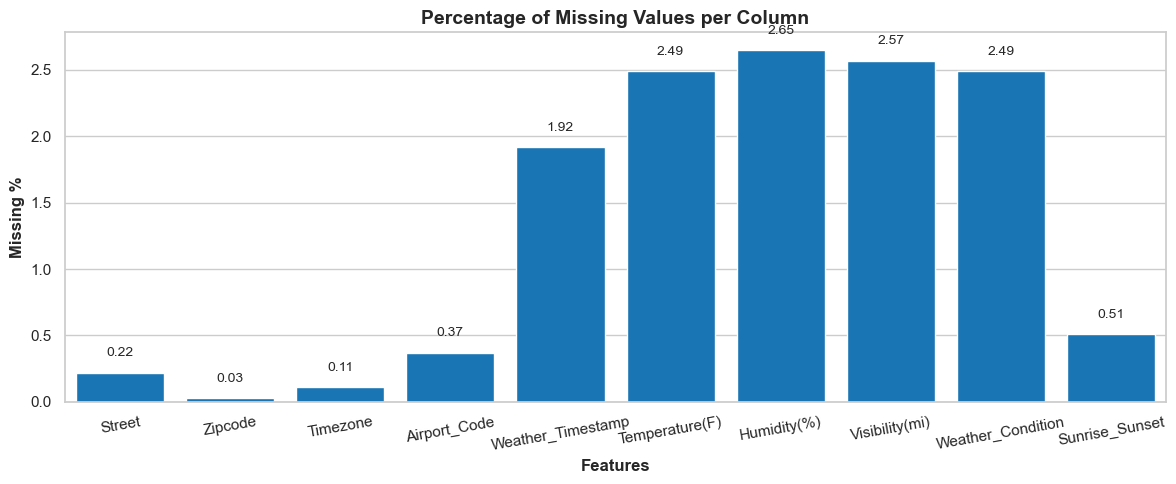

In [21]:
missing_plot = missing_percent[missing_percent > 0] 
plt.figure(figsize=(12,5))
ax = sns.barplot(x=missing_plot.index, y=missing_plot.values, color='#007acc')
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.1, f'{height:.2f}', 
            ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=10, ha='center')
plt.xlabel('Features', fontsize=12, fontweight='bold')
plt.ylabel('Missing %', fontsize=12, fontweight='bold')
plt.title('Percentage of Missing Values per Column', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

- Features such as **Sunrise_Sunset** and **Airport_Code** have a very low missing percentage (<1%), so rows with missing values can be removed since the number is negligible compared to the total dataset size.
- For features like **Visibility (mi)** and **Temperature (F)**, consider using the median for imputation (since the data contains outliers, the median is better than the mean).
- The weather-related features such as Humidity(%), Visibility(mi), Temperature(F), and Weather_Condition have more missing values compared to the features related to road conditions such as Amenity, Junction, etc.

## Outlier Detection

In [22]:
# Detect outliers using the IQR method
Q1 = df_train[numerical_vars].quantile(0.25)
Q3 = df_train[numerical_vars].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df_train[numerical_vars] < (Q1 - 1.5 * IQR)) | 
              (df_train[numerical_vars] > (Q3 + 1.5 * IQR))).sum()

print("Number of outliers (per column):\n", outliers)

Number of outliers (per column):
 Severity          169722
Latitude               0
Longitude              0
Distance(mi)      248427
Temperature(F)     15524
Humidity(%)            0
Visibility(mi)    462310
dtype: int64


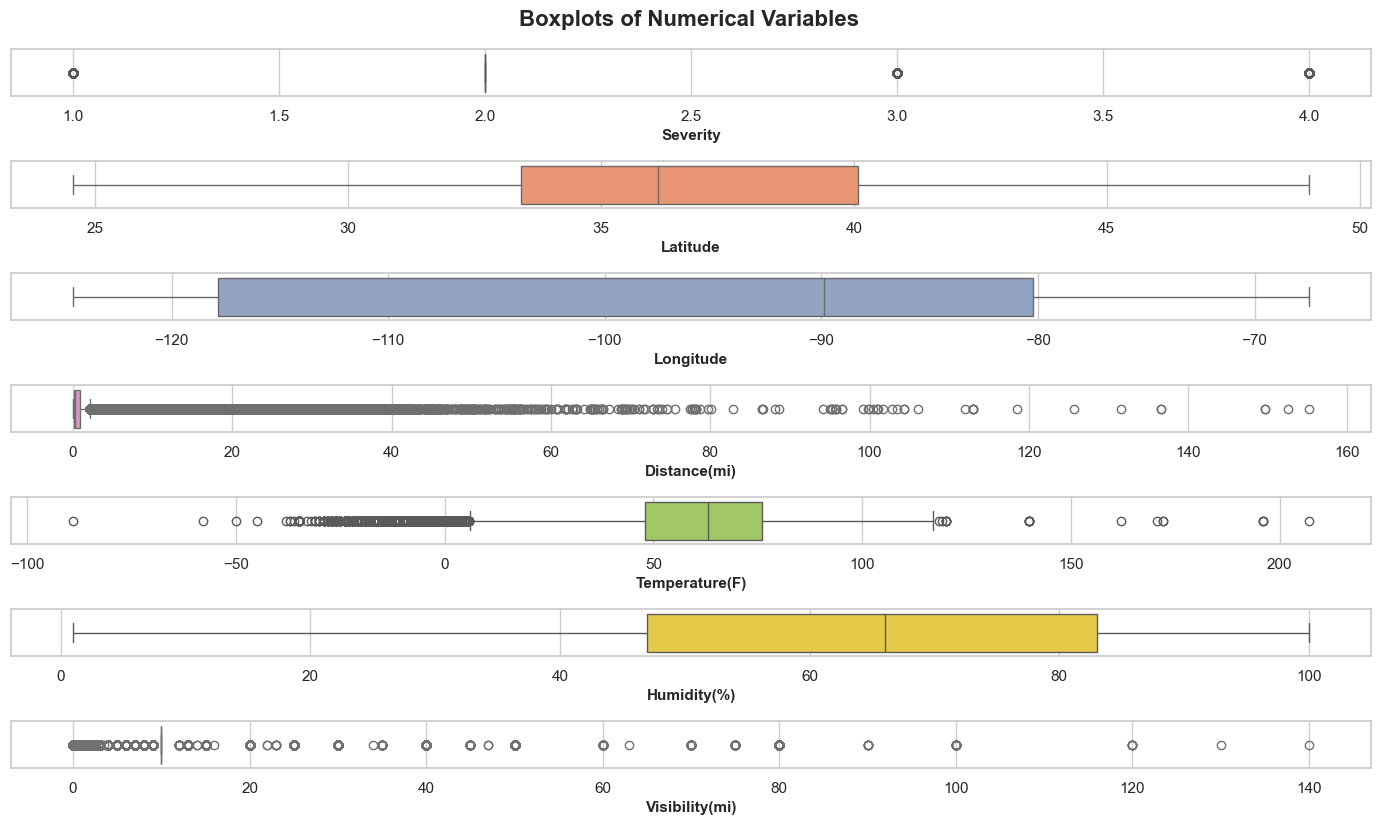

In [24]:
palette_color = sns.color_palette("Set2")

n = len(numerical_vars)

plt.figure(figsize=(14, n * 1.2))

for i, col in enumerate(numerical_vars, 1):
    plt.subplot(n, 1, i)
    sns.boxplot(
        x=df_train[col],
        orient='h',
        color=palette_color[i - 1]
    )
    plt.xlabel(col, fontweight='bold', fontsize=11)

plt.suptitle("Boxplots of Numerical Variables", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

- Values such as **Temperature** 207°F or -89°F are measurement errors and need to be removed.
- **Distance (mi)** has many upper outliers. These represent severe, large-scale accidents (long traffic jams, long processing times).
- Most variables (e.g., **Distance (mi)**, **Visibility (mi)**) are right-skewed. This reflects the reality that most accidents are small-scale, while large-scale accidents are rare.

## Leakage Check

In [25]:
target_var = 'Severity'
print("Potential data leakage check:")
print("Columns highly correlated with target may indicate leakage.")
corr_target = df_train[numerical_vars].corr()[target_var].drop(target_var)
leak_cols = corr_target[abs(corr_target) > 0.9].index.tolist()
if leak_cols:
    print(f"Potential leakage columns (corr > 0.9 with target): {leak_cols}\n")
else:
    print("No obvious leakage columns detected based on correlation.\n")

Potential data leakage check:
Columns highly correlated with target may indicate leakage.
No obvious leakage columns detected based on correlation.



## VIF Check

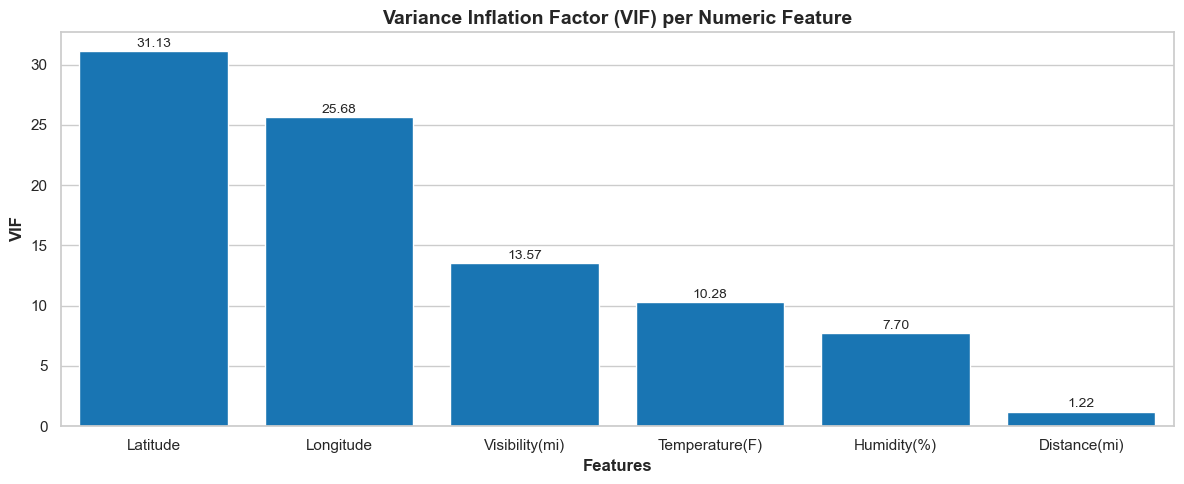

In [26]:
target_var = 'Severity'
X_numeric = df_train[numerical_vars].drop(columns=[target_var])

vif_data = pd.DataFrame()
vif_data['Feature'] = X_numeric.columns
vif_data['VIF'] = [variance_inflation_factor(X_numeric.dropna().values, i) 
                   for i in range(X_numeric.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)

plt.figure(figsize=(12,5))
ax = sns.barplot(x='Feature', y='VIF', data=vif_data, color='#007acc')

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.1, f'{height:.2f}', 
            ha='center', va='bottom', fontsize=10)
    
plt.xticks(rotation=0, ha='center')
plt.xlabel('Features', fontsize=12, fontweight='bold')
plt.ylabel('VIF', fontsize=12, fontweight='bold')
plt.title('Variance Inflation Factor (VIF) per Numeric Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

- **Latitude (37.64)** and **Longitude (25.73)** have very high VIF values. This is understandable because accidents often concentrate in specific geographic clusters, causing latitude and longitude to have a strong linear relationship within the geographical space of the United States.
- **Temperature (F) (11.09)** has a VIF > 10, indicating a strong correlation with other variables (possibly Humidity or Visibility).
- **Humidity (%) (8.27)** and **Visibility (mi) (13.91)** also have relatively high VIF values, reflecting the natural physical relationship between weather factors.

# **Exploratory Data Analysis**

## **Univariate Analysis**

## Numerical features distribution

In this section, we will examine the distribution of numerical features. To make the analysis more effective, we divide the features into two groups:
- Environmental Features: Distance, Temperature, Humidity, Visibility.
- Geospatial Features: Latitude and Longitude (to be visualized using a map).
- Target: Severity

**Distance, Temperature, Humidity, Visibility**

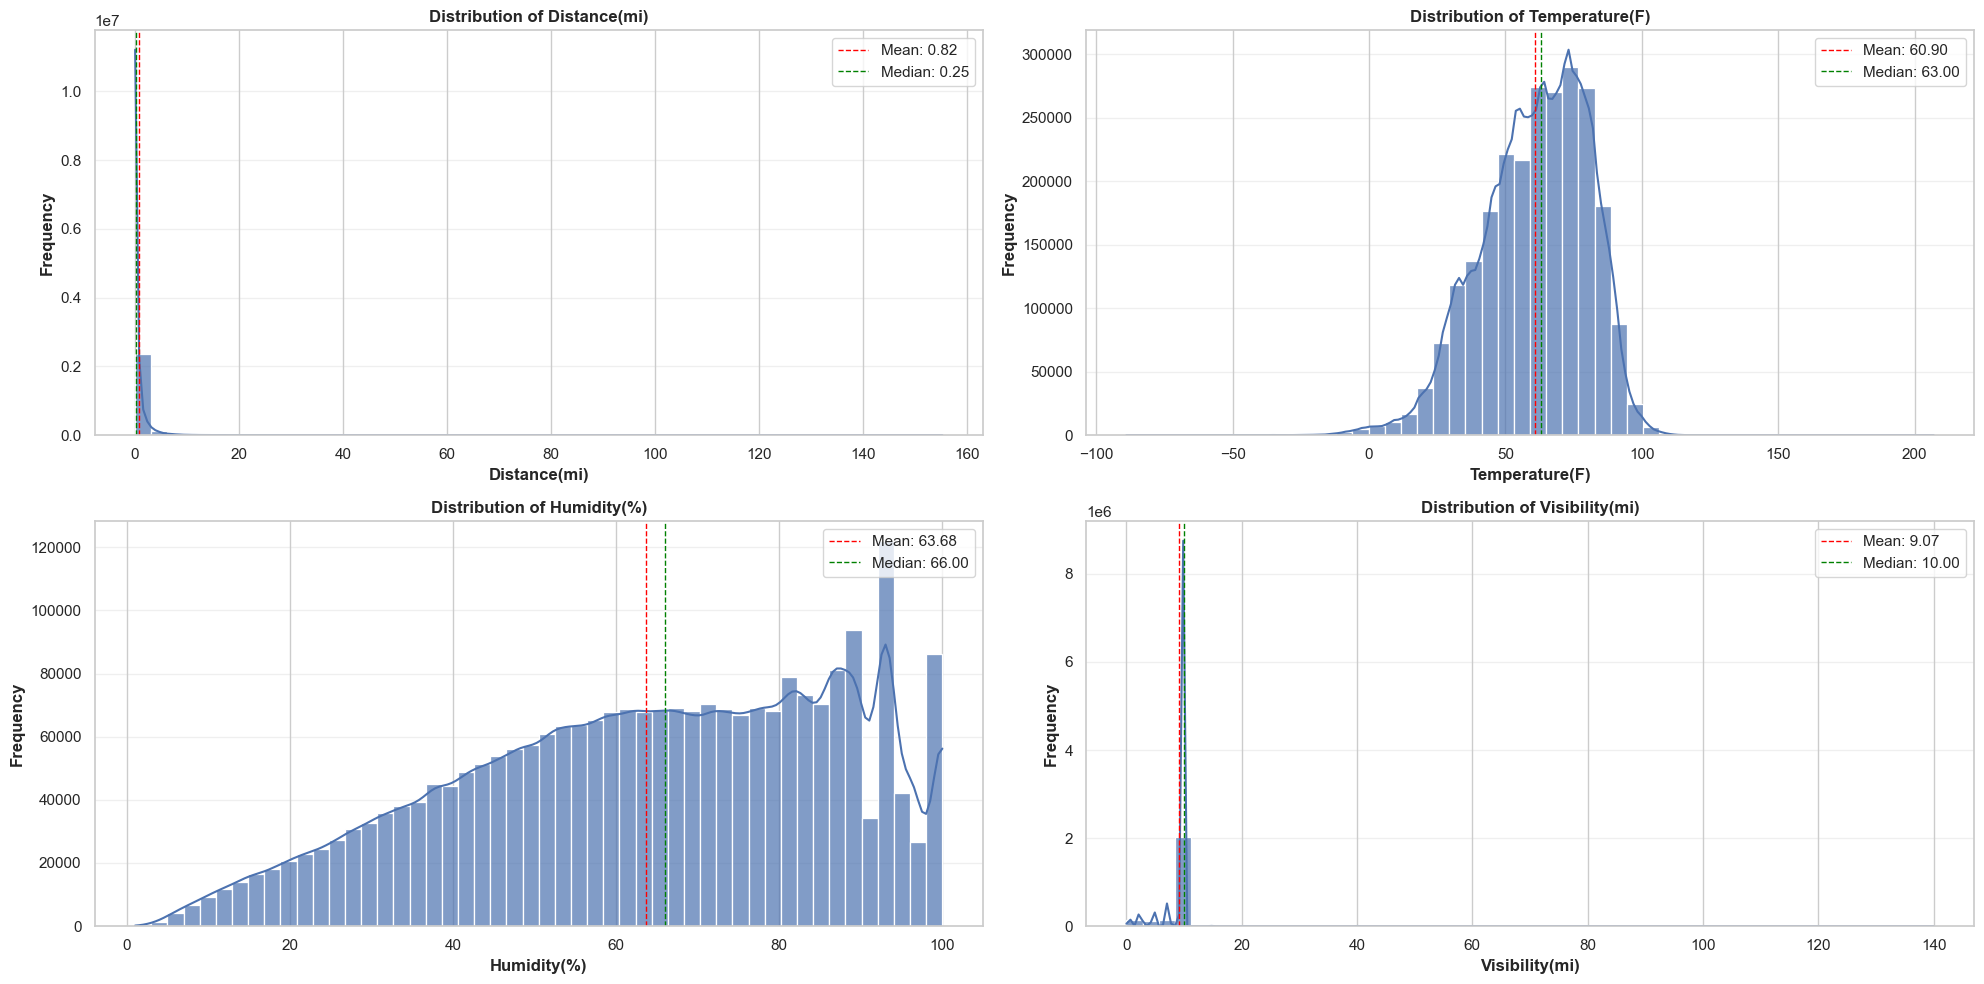

In [27]:
numerical_cols = df_train.select_dtypes(include=['int64', 'float64']).columns.drop(['Severity', 'Latitude', 'Longitude'])

n_cols = len(numerical_cols)
n_rows = n_cols // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(20, n_rows * 5))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        sns.histplot(df_train[col], kde=True, bins=50, ax=axes[idx], alpha=0.7)
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col, fontweight='bold')
        axes[idx].set_ylabel('Frequency', fontweight='bold')
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Add mean and median lines
        axes[idx].axvline(df_train[col].mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {df_train[col].mean():.2f}')
        axes[idx].axvline(df_train[col].median(), color='green', linestyle='--', linewidth=1, label=f'Median: {df_train[col].median():.2f}')

        axes[idx].legend(loc='upper right')

for idx in range(len(numerical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

- **Distance (mi)**: The distribution is strongly right-skewed. Most accidents occur over very short distances (< 1 mile). However, there are outliers that pull the Mean (0.82) significantly higher than the Median (0.25).
- **Temperature (°F) & Humidity (%)**: Both have relatively normal distributions (similar to a bell curve), reflecting the variety of climates across the U.S.
- **Visibility (mi)**: The data is primarily concentrated at 10 miles (the standard maximum visibility). This indicates that most accidents happen under clear visibility conditions, with no significant visibility restrictions.

**Longtitude, Lattitude**

In [28]:
import folium
# Create a base map
m = folium.Map(location=[df_train['Latitude'].mean(), df_train['Longitude'].mean()], zoom_start=10)

# Create a random sample of 1000 rows from df_train
df_sample = df_train.sample(n=1000, random_state=1)

# Add points to the map
for idx, row in df_sample.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=row['Severity']
    ).add_to(m)

# Display the map
m

Observing the density of points on the map, we can clearly see the distribution across different **Timezones**:
- **US/Eastern:**
    + This is the area with the highest density of accident points (particularly in the Northeast and Florida).
    + This aligns perfectly with the Timezone distribution chart above, where US/Eastern accounts for the largest number of accidents (~1.1 million).
- **US/Pacific:**
    + The points are heavily concentrated along the West Coast, especially in California.
    + This is the second-highest contributor to the accident count in the dataset.
- **US/Central:**
    + The accident points are more dispersed, with concentrations around major cities in the central and southern regions (such as Texas, Illinois).
- **US/Mountain:**
    + The least dense area, which aligns with the fact that this region has mountainous terrain and a lower population density.

**Conclusion**: Traffic accidents tend to be heavily concentrated in densely populated urban areas and major transportation networks, rather than being evenly spread across the country.

**Target variable**

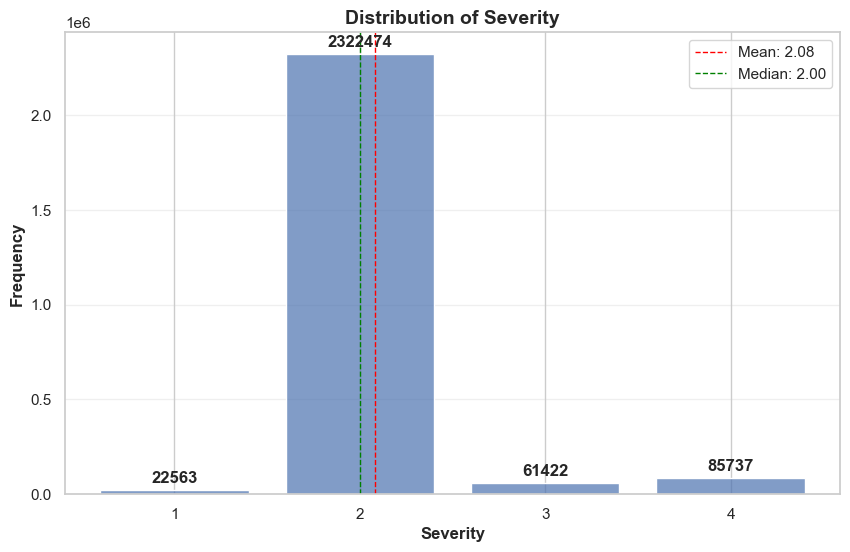

In [49]:
target_var = 'Severity'

plt.figure(figsize=(10, 6))

ax = sns.histplot(df_train[target_var], discrete=True, kde=False, alpha=0.7, shrink=0.8)
plt.title(f'Distribution of {target_var}', fontsize=14, fontweight='bold')
plt.xlabel(target_var, fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.grid(axis='y', alpha=0.3)

plt.xticks([1, 2, 3, 4])

ax.bar_label(ax.containers[0], fmt='%d', label_type='edge', padding=3, fontweight='bold')

# Mean & Median lines
plt.axvline(df_train[target_var].mean(), color='red', linestyle='--', linewidth=1,
            label=f'Mean: {df_train[target_var].mean():.2f}')
plt.axvline(df_train[target_var].median(), color='green', linestyle='--', linewidth=1,
            label=f'Median: {df_train[target_var].median():.2f}')

plt.legend(loc='upper right')
plt.show()

- **Severe Data Imbalance (High Imbalance):**
    + The majority of the data samples are concentrated at Severity 2 (dominating the proportion).
    + Severity 1 and Severity 4 are very rare compared to Levels 2 and 3.
    + Consequence: If not addressed, the Machine Learning model will tend to predict everything as "Severity 2" to achieve high accuracy artificially, but it will fail to forecast more serious incidents (Class 4).
- **Statistical Characteristics:** The Mean and Median values are close to level 2, reinforcing the skewness of the data toward the lighter severity levels.

## Categorical features distribution

To effectively visualize categorical features, we divide them into two groups based on the number of unique values (Cardinality):
- Low Cardinality: Features with few unique values (e.g., **Timezone**, **Sunrise_Sunset**). We will plot the entire distribution.
- High Cardinality: Features with many unique values (e.g., **City**, **State**, **Weather_Condition**). We will only plot the Top 10 most frequent values to avoid cluttering the chart.

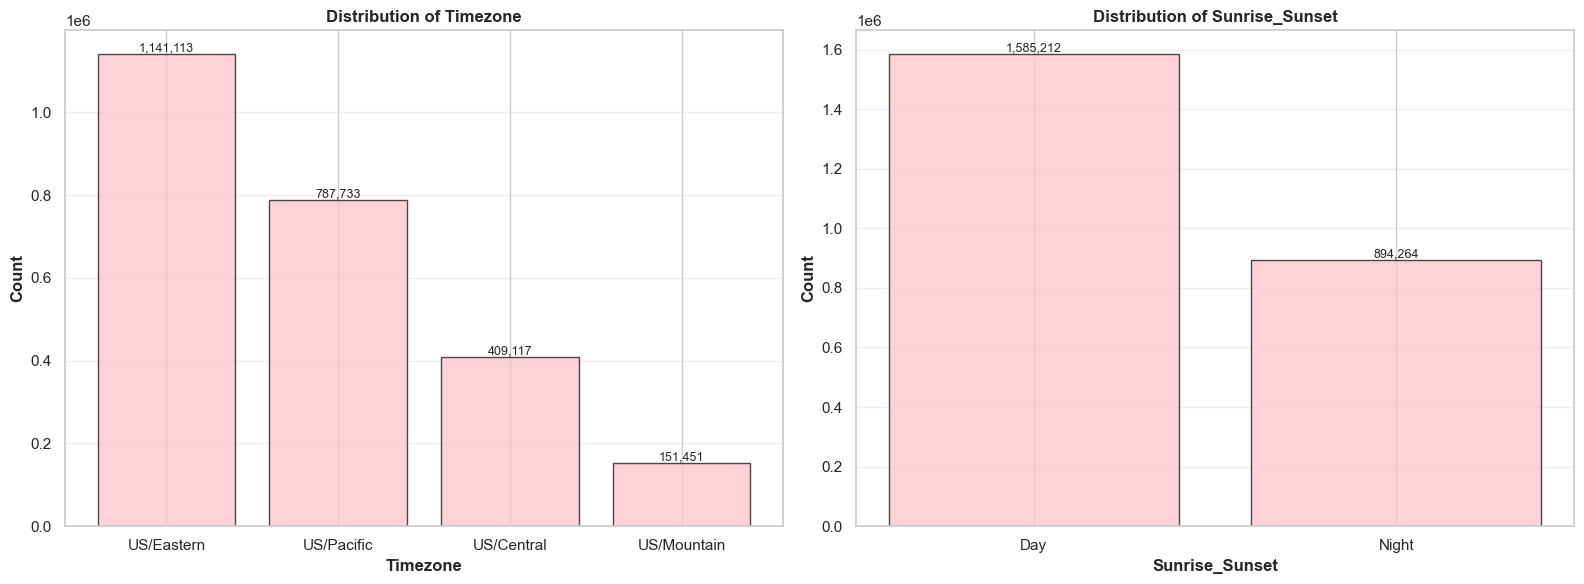

In [50]:
categorical_cols = df_train.select_dtypes(include=['object']).columns.drop(['ID', 'Start_Time', 'End_Time', 'Description', 'Street', 'Zipcode', 'Weather_Timestamp', 'City', 'County', 'State', 'Airport_Code', 'Weather_Condition'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    if idx < len(axes):
        value_counts = df_train[col].value_counts()
        axes[idx].bar(range(len(value_counts)), value_counts.values, color='pink', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col, fontweight='bold')
        axes[idx].set_ylabel('Count', fontweight='bold')
        axes[idx].set_xticks(range(len(value_counts)))
        axes[idx].set_xticklabels(value_counts.index, rotation=0, ha='center')
        axes[idx].grid(axis='y', alpha=0.3)
        
        for i, v in enumerate(value_counts.values):
            axes[idx].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

# Hide extra subplots
for idx in range(len(categorical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

- **Timezone**: The majority of accidents in the dataset occur in the US/Eastern timezone (East Coast), followed by US/Pacific. This correlates with the higher population density in these regions.
- **Sunrise_Sunset**: Accidents that occur during Daytime overwhelmingly outnumber those that happen at Night. This is reasonable because traffic volume is much higher during the day than at night, even though driving conditions are generally more dangerous at night.

### Top 10 most frequent values of High Cardinality Features

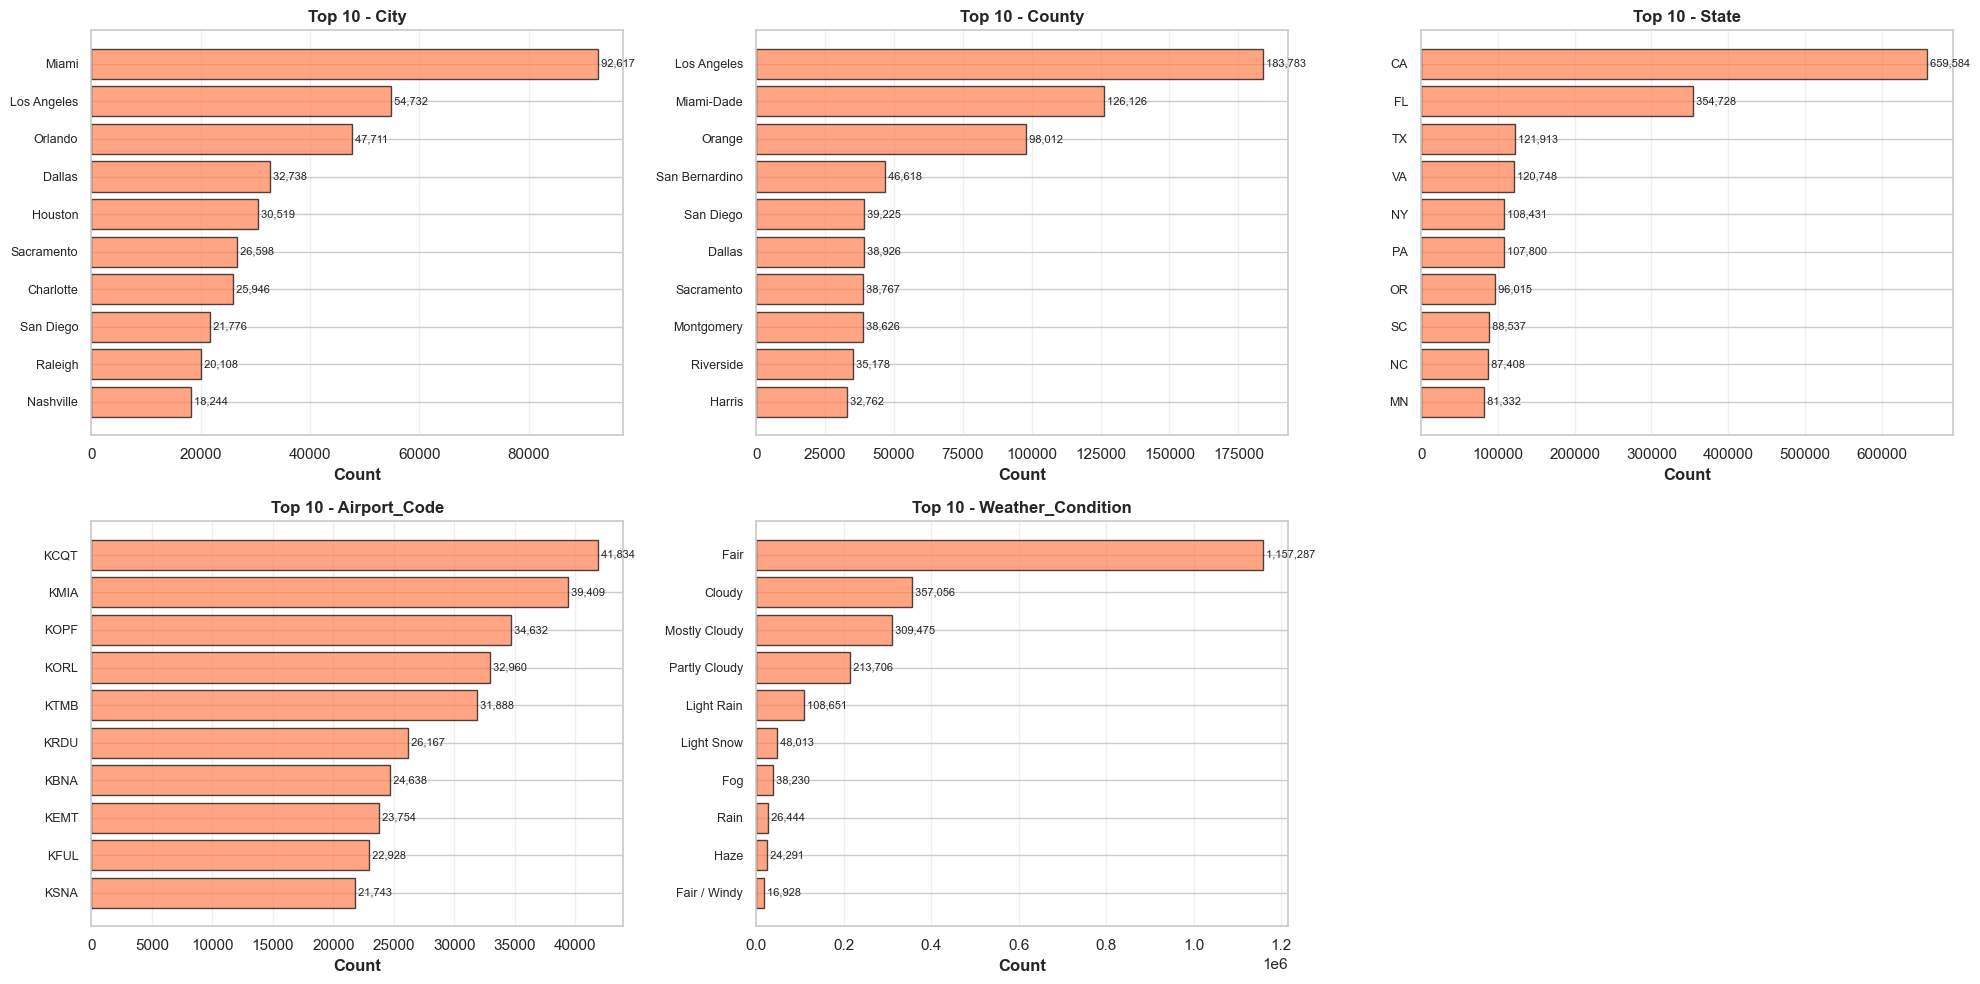

In [51]:
high_cardinality_cols = ['City', 'County', 'State', 'Airport_Code', 'Weather_Condition']

n_cols = len(high_cardinality_cols)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(20, n_rows * 5))
axes = axes.flatten()

for idx, col in enumerate(high_cardinality_cols):
    if idx < len(axes):
        value_counts = df_train[col].value_counts().head(10)
        
        value_counts = value_counts.iloc[::-1]
        
        axes[idx].barh(range(len(value_counts)), value_counts.values, 
                      color='coral', edgecolor='black', alpha=0.7)
        axes[idx].set_yticks(range(len(value_counts)))
        axes[idx].set_yticklabels(value_counts.index, fontsize=9)
        axes[idx].set_title(f'Top 10 - {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Count', fontweight='bold')
        axes[idx].grid(axis='x', alpha=0.3)
        
        for i, v in enumerate(value_counts.values):
            axes[idx].text(v, i, f' {v:,}', va='center', fontsize=8)

for idx in range(len(high_cardinality_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

- **City**: Miami ranks first in the number of recorded accidents (over 90k incidents), followed by Los Angeles and Orlando.
- **State**: California (CA) has a significantly higher number of accidents (almost double that of the second-highest state, Florida - FL). The top 3 states (CA, FL, TX) are all large in both population and area.
- **Weather Condition**:
    + It is notable that the majority of accidents occur under Fair (Clear/Good) weather conditions.
    + Severe weather conditions such as Rain, Snow, and Fog appear much less frequently in the Top 10.
    + Explanation: Although bad weather increases risk, most of the time the weather is "normal," so the total number of accidents occurring during clear weather still makes up the majority (due to higher traffic volume and the more frequent occurrence of good weather).

## **Multivariate Analysis**

Chia thành các nhóm biến để phân tích về mức độ ảnh hưởng với Severity

## Location feature vs Severity

In [ ]:
numerical_location_cols_for_analysis = df_train[['Latitude', 'Longitude', 'Distance(mi)']]

n_cols = len(numerical_location_cols_for_analysis)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(20, n_rows * 5))
axes = axes.flatten()

for idx, col in enumerate(numerical_location_cols_for_analysis):
    if idx < len(axes):
        sns.boxplot(data=df_train, x='Severity', y=col, 
                    ax=axes[idx], 
                    color='#85C1E9',
                    showfliers=True) 
        
        axes[idx].set_title(f'{col} vs Severity', fontsize=16, fontweight='bold')
        axes[idx].set_xlabel('Severity', fontweight='bold', fontsize=12)
        axes[idx].set_ylabel(col, fontweight='bold', fontsize=12)
        axes[idx].grid(axis='y', alpha=0.3)

# Hide extra subplots
for idx in range(len(numerical_location_cols_for_analysis), len(axes)):
    axes[idx].axis('off')
    
plt.suptitle('Analysis of Numerical Variables vs Severity', 
             fontsize=18, fontweight='bold', y=0.998)
plt.tight_layout()
plt.show()

In [ ]:
categorical_location_cols_for_analysis = df_train[['Street', 'City', 'State', 'City', 'County', 'Zipcode', 'Timezone', 'Airport_Code']]

n_cols = len(categorical_location_cols_for_analysis)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(20, n_rows * 6)) 
axes = axes.flatten()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for idx, feature in enumerate(categorical_location_cols_for_analysis):
    if idx < len(axes):
        if df_train[feature].nunique() > 10:
            top_categories = df_train[feature].value_counts().head(10).index
            top_categories = top_categories[::-1]
            plot_df = df_train[df_train[feature].isin(top_categories)]
            title_suffix = ' (Top 10)'
        else:
            plot_df = df_train
            title_suffix = ''
        
        severity_counts = plot_df.groupby([feature, 'Severity']).size().unstack(fill_value=0)

        if df_train[feature].nunique() > 10:
             severity_counts = severity_counts.reindex(top_categories)
        
        severity_counts = severity_counts.reindex(columns=[1, 2, 3, 4], fill_value=0)
        severity_counts = severity_counts[[4, 3, 2, 1]]

        severity_counts.plot(kind='barh', ax=axes[idx], stacked=False, 
                             logx=True, width=0.8,
                             color=colors)
        
        axes[idx].set_title(f'{feature} vs Severity{title_suffix}', fontsize=16, fontweight='bold')
        axes[idx].set_ylabel(feature, fontweight='bold', fontsize=12)
        axes[idx].set_xlabel('Count (Log Scale)', fontweight='bold', fontsize=12)
        axes[idx].tick_params(axis='y', labelsize=11)

        handles, labels = axes[idx].get_legend_handles_labels()
        axes[idx].legend(handles[::-1], labels[::-1], title='Severity', fontsize=8, loc='lower right')
        
        axes[idx].grid(axis='x', alpha=0.3)

# Hide extra subplot
for i in range(len(categorical_location_cols_for_analysis), len(axes)):
    axes[i].axis('off')

plt.suptitle('Analysis of Location Variables vs Severity (Log Scale)', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## Road Condition feature vs Severity

vẽ biểu đồ cho các biến bool là Amenity, Crossing, Junction, Railway, Station, Stop, Traffic_Signal

## Weather feature vs Severity

In [ ]:
numerical_weather_cols_for_analysis = df_train[['Temperature(F)', 'Humidity(%)', 'Visibility(mi)']]

n_cols = len(numerical_weather_cols_for_analysis)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(20, n_rows * 5))
axes = axes.flatten()

for idx, col in enumerate(numerical_weather_cols_for_analysis):
    if idx < len(axes):
        sns.boxplot(data=df_train, x='Severity', y=col, 
                    ax=axes[idx], 
                    color='#85C1E9',
                    showfliers=True) 
        
        axes[idx].set_title(f'{col} vs Severity', fontsize=16, fontweight='bold')
        axes[idx].set_xlabel('Severity', fontweight='bold', fontsize=12)
        axes[idx].set_ylabel(col, fontweight='bold', fontsize=12)
        axes[idx].grid(axis='y', alpha=0.3)

# Hide extra subplots
for idx in range(len(numerical_weather_cols_for_analysis), len(axes)):
    axes[idx].axis('off')
    
plt.suptitle('Analysis of Numerical Variables vs Severity', 
             fontsize=18, fontweight='bold', y=0.998)
plt.tight_layout()
plt.show()

In [ ]:
categorical_weather_cols_for_analysis = df_train[['Weather_Condition', 'Sunrise_Sunset']]

n_cols = len(categorical_weather_cols_for_analysis)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(20, n_rows * 6)) 
axes = axes.flatten()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for idx, feature in enumerate(categorical_weather_cols_for_analysis):
    if idx < len(axes):
        if df_train[feature].nunique() > 10:
            top_categories = df_train[feature].value_counts().head(10).index
            top_categories = top_categories[::-1]
            plot_df = df_train[df_train[feature].isin(top_categories)]
            title_suffix = ' (Top 10)'
        else:
            plot_df = df_train
            title_suffix = ''
        
        severity_counts = plot_df.groupby([feature, 'Severity']).size().unstack(fill_value=0)

        if df_train[feature].nunique() > 10:
             severity_counts = severity_counts.reindex(top_categories)
        
        severity_counts = severity_counts.reindex(columns=[1, 2, 3, 4], fill_value=0)
        severity_counts = severity_counts[[4, 3, 2, 1]]

        severity_counts.plot(kind='barh', ax=axes[idx], stacked=False, 
                             logx=True, width=0.8,
                             color=colors)
        
        axes[idx].set_title(f'{feature} vs Severity{title_suffix}', fontsize=16, fontweight='bold')
        axes[idx].set_ylabel(feature, fontweight='bold', fontsize=12)
        axes[idx].set_xlabel('Count (Log Scale)', fontweight='bold', fontsize=12)
        axes[idx].tick_params(axis='y', labelsize=11)

        handles, labels = axes[idx].get_legend_handles_labels()
        axes[idx].legend(handles[::-1], labels[::-1], title='Severity', fontsize=8, loc='lower right')
        
        axes[idx].grid(axis='x', alpha=0.3)

# Hide extra subplot
for i in range(len(categorical_weather_cols_for_analysis), len(axes)):
    axes[i].axis('off')

plt.suptitle('Analysis of Weather Variables vs Severity (Log Scale)', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

- **Latitude & Longitude**:
    + There is a slight difference in the distribution of latitude (Latitude) and longitude (Longitude) across severity levels.
    + This suggests that certain geographic areas (e.g., specific states or highways) may have a tendency to experience more severe accidents (Severity 3 & 4) compared to other areas.
- **Distance(mi)**:
    + This is one of the important variables. Although the median value is low across all severity levels (close to 0), Severity 4 tends to have longer "tails" (with higher values).
    + Explanation: Severity 4 typically represents severe accidents that cause long traffic congestion or road closures, so the affected Distance is greater compared to minor accidents (Severity 1, 2).
- **Temperature, Humidity, Visibility**:
    + **Temperature(F) & Humidity(%)**: The box plots are quite similar in size and position across severity levels, indicating that average temperature and humidity are not strong discriminators for severity levels.
    + **Visibility(mi)**: Most accidents occurred with good visibility (around 10 miles). However, there are many outliers at low visibility. This could suggest that while accidents still occur under low visibility (fog, heavy rain), they do not necessarily always lead to Severity 4.

**Conclusion**:
- Individual weather variables do not show clear separation between severity levels.
- The **Distance(mi)** and **Latitude & Longitude** have the potential to provide more useful information for prediction models.

## Categorical Features vs Severity

In this section, we use a horizontal bar chart to compare the frequency of accident severity levels (**Severity**) across different categorical groups (such as City, State, Weather, etc.).

**Why Log Scale?**
- **Extreme data imbalance**: In this dataset, the number of accidents at severity level **Severity 2** typically dominates (with hundreds of thousands of samples), while **Severity 1** or **Severity 4** might only have a few thousand or even just a few hundred samples.
- **Display issues**: If plotted on a regular (linear) scale, the bars for **Severity 2** would be extremely tall, making the bars for **Severity 1, 3, and 4** tiny and hard to compare.

Therefore, we switched the x-axis to a Logarithmic Scale (Log Scale) to reduce the display gap between large and small groups, allowing us to observe the trends for all severity levels on the same chart.

- **City, County, State:**
    + Although Severity 2 is the most common in most areas, the rates of Severity 3 and 4 vary by region.
    + For example, in some states or large cities, the rate of severe accidents (red - Severity 4) tends to be higher compared to other areas, possibly due to high traffic density or higher speeds on highways.
- **Timezone & Sunrise_Sunset:**
    + **Timezone**: Regardless of the timezone, Severity 2 still dominates. However, the Eastern region has a significantly higher number of severe accidents (Severity 3 & 4) compared to the Mountain region, likely because traffic volume is much higher there.
    + **Sunrise_Sunset**: Nighttime accidents (Night) are fewer in total compared to daytime accidents (Day), but the proportion of severe accidents (Severity 3 & 4) relative to the total number of nighttime accidents seems higher. This aligns with the hypothesis that poor visibility and driver fatigue at night increase the risk of severe accidents.
- **Airport_Code:**
    + The most frequent codes, such as KMIA (Miami Intl), KORL (Orlando), or KCQT (Los Angeles area), completely align with the results of the City and State analysis above. This reinforces the assertion that Florida and California are "hotspots."
- **Weather_Condition:**
    + Bad weather conditions such as Rain, Snow, and Fog are associated with the presence of Severity 3 and 4.
    + Notably, even under Fair weather conditions, the number of severe accidents remains quite high. This reminds us that weather is just one factor; driving behavior and road conditions also play an equally important role.

**Conclusion:**
- These categorical variables contain important information for distinguishing accident severity.
- The use of Log Scale has helped highlight the presence of severe accidents (which are less common) across different data groups.

## Correlation Matrix

### Correlation Matrix for Numerical Features

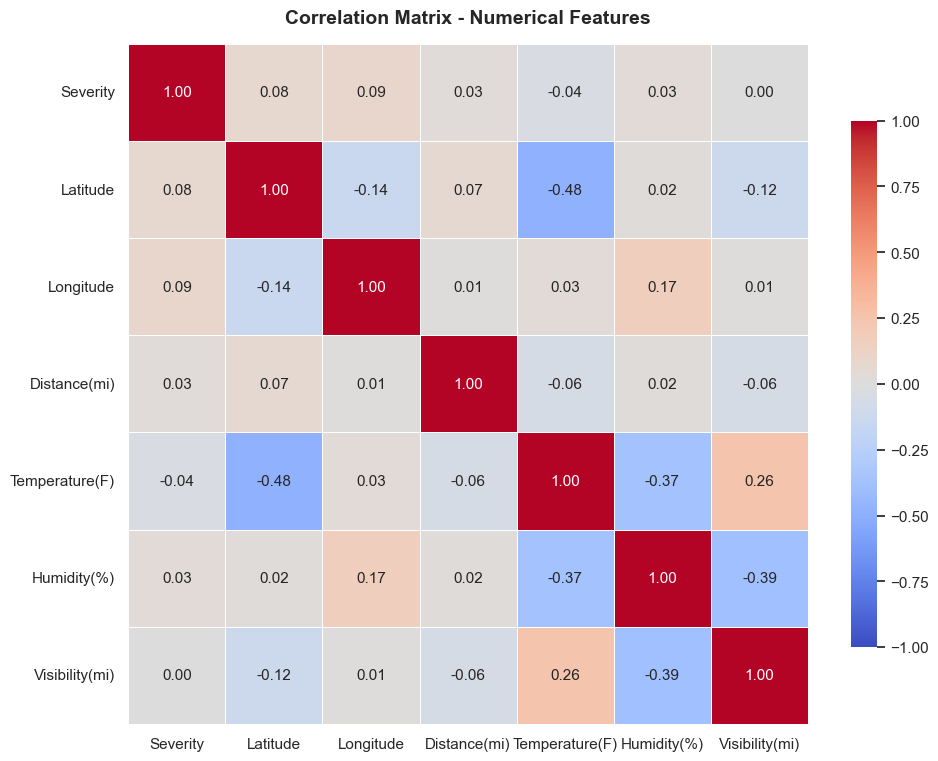

Highly Correlated Feature Pairs (|correlation| > 0.7)

No feature pairs with |correlation| > 0.7 found.


In [22]:
numerical_cols = df_train.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df_train[numerical_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.75},
            vmin=-1, vmax=1,
            annot_kws={"size": 11})

plt.title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=0, ha='center')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Highly Correlated Feature Pairs (|correlation| > 0.7)")

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    for var1, var2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"{var1:30s} <-> {var2:30s} : {corr:7.3f}")
else:
    print("\nNo feature pairs with |correlation| > 0.7 found.")

- **Relationship with Target Variable (Severity):**
    + All quantitative variables have very low correlation with Severity (close to 0).
    + The highest correlations are with Longitude (0.09) and Latitude (0.08).

=> This suggests that the severity of an accident does not depend linearly on any single factor (such as temperature, humidity, or distance). Severe accidents result from a complex interaction of multiple factors, or this relationship could be non-linear.
- **Correlation Between Input Features:**
    + **Humidity vs Visibility (-0.39)**: Negative correlation. As humidity increases (rain, fog), visibility (Visibility) decreases.
    + **Humidity vs Temperature (-0.37)**: There is a slight negative correlation in this dataset.

### Correlation Matrix for Categorical Features (Cramér's V)

To ensure statistical effectiveness and significance, we only selected **State** and **Weather_Condition**, excluding features such as **City** and **Street** for the following reasons:
- **Level of categorization (Cardinality)**: State (~50) and Weather (~100) have a moderate number of values, making them easy to manage. In contrast, City and Street have thousands of values, which could clutter the matrix.
- **Generalization capability**: Learning based on State allows the model to generalize well to new data. Focusing on individual City details risks Overfitting (memorization).
- **Business significance**: State represents local laws and terrain, while Weather directly impacts driving conditions. The geographical information of City is essentially captured by the coordinates (Lat/Long).
- **Technical performance**: Handling thousands of categories would cause the Curse of Dimensionality, slowing down the training process and consuming unnecessary resources.

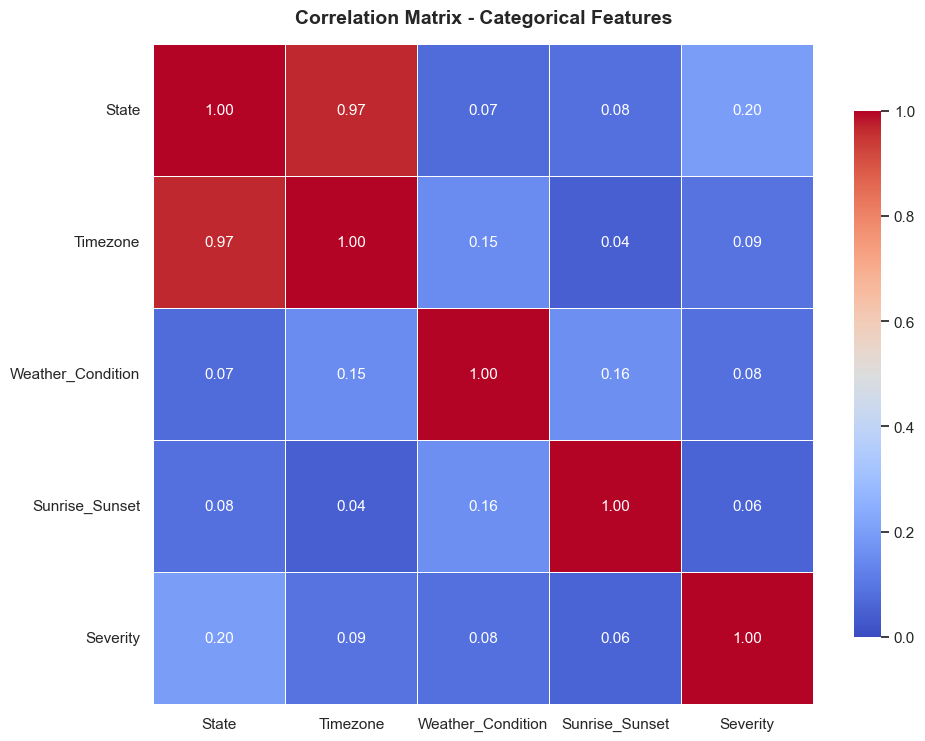

Strongly Associated Categorical Pairs (Cramér's V > 0.5)
State <-> Timezone : 0.968


In [32]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """
    Calculate Cramér's V statistic for categorical-categorical association.
    Returns a value between 0 and 1, where:
    - 0 = no association
    - 1 = perfect association
    """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    
    if min_dim == 0:
        return 0
    
    cramers_v_stat = np.sqrt(chi2 / (n * min_dim))
    return cramers_v_stat

# Select categorical features (exclude high cardinality and ID-like columns)
categorical_cols_for_corr = df_train.select_dtypes(include=['object']).columns.drop(
    ['ID', 'Start_Time', 'End_Time', 'Description', 'Street', 'Zipcode', 
     'Weather_Timestamp', 'City', 'County', 'Airport_Code'], errors='ignore'
).tolist()

# Add Severity to analyze its relationship with categorical features
if 'Severity' not in categorical_cols_for_corr:
    categorical_cols_for_corr.append('Severity')

# Calculate Cramér's V for all pairs
n_features = len(categorical_cols_for_corr)
cramers_matrix = np.zeros((n_features, n_features))

for i in range(n_features):
    for j in range(n_features):
        if i == j:
            cramers_matrix[i, j] = 1.0
        elif i < j:
            v = cramers_v(df_train[categorical_cols_for_corr[i]], 
                         df_train[categorical_cols_for_corr[j]])
            cramers_matrix[i, j] = v
            cramers_matrix[j, i] = v

cramers_df = pd.DataFrame(cramers_matrix, 
                          index=categorical_cols_for_corr, 
                          columns=categorical_cols_for_corr)

# Visualize
plt.figure(figsize=(10, 8))

sns.heatmap(cramers_df, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0.5,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.75},
            vmin=0, vmax=1,
            annot_kws={"size": 11})

plt.title("Correlation Matrix - Categorical Features", 
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=0, ha='center')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Strongly Associated Categorical Pairs (Cramér's V > 0.5)")

strong_associations = []
for i in range(len(categorical_cols_for_corr)):
    for j in range(i+1, len(categorical_cols_for_corr)):
        v_value = cramers_df.iloc[i, j]
        if v_value > 0.5:
            strong_associations.append((
                categorical_cols_for_corr[i], 
                categorical_cols_for_corr[j], 
                v_value
            ))

if strong_associations:
    for var1, var2, v_val in sorted(strong_associations, key=lambda x: x[2], reverse=True):
        print(f"{var1:5s} <-> {var2:5s} : {v_val:.3f}")
else:
    print("\nNo categorical pairs with Cramér's V > 0.5 found.")

- **Strongest correlation (State <-> Timezone): 0.968**
    + The time zone (Timezone) is almost entirely dependent on the geographical location (State). Knowing the state almost immediately determines the time zone. Therefore, these two features carry redundant information if both are included in the model.
- **Correlation with the target variable (Severity):**
    + State (0.20): Has the most significant correlation with Severity among the selected features. This supports the initial observation that geographical location (at the state level) is an important factor influencing the severity of accidents.
    + Other variables: Timezone (0.09), Weather_Condition (0.08), Sunrise_Sunset (0.06) all have weak correlations with Severity.
- **Correlation between environmental variables:**
    + Weather_Condition and Sunrise_Sunset have a rather weak correlation with each other (0.16) and with geographical features (State/Timezone). This suggests that they provide independent information regarding the environment and time of the accident.

**Conclusion**
- **Multicollinearity**: The strong relationship between State and Timezone should be noted. Consider removing Timezone when building the model to reduce noise, as State already contains most of the location information.
- **Important factors**: Among the macro-level categorical features, State seems to be the most powerful factor for classifying the severity of the accident.

## **Build Baseline Model**

In this step, we build a baseline model to assess initial forecasting performance.
- Features (X): To simplify the baseline model, we temporarily exclude high-cardinality categorical variables such as **City, Street, Zipcode, and time-related variables**. We only keep numerical variables such as **Latitude, Longitude, Distance, Temperature, etc**.
- Target (y): The target variable is **Severity**.
- Train/Test Split: We split the data in an 80% train - 20% test ratio with random_state=42 to ensure reproducibility.

In [11]:
target_var = 'Severity'
y = df_train[target_var]
X = df_train.drop(columns=[target_var])

In [12]:
model_results = {}

In [13]:
drop_cols = [
    'ID','Start_Time','End_Time','Description','Street','City','County','State',
    'Zipcode','Timezone','Airport_Code','Weather_Timestamp','Weather_Condition','Sunrise_Sunset'
]

X_model = X.drop(columns=drop_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.2, random_state=42
)

- Algorithms Used: XGBoost, LightGBM, Random Forest, CatBoost
- Note on Handling Missing Values:
    + XGBoost & LightGBM: These algorithms can handle missing values on their own, so we use the original dataset (X_train).
    + Random Forest & CatBoost: For this run, we use the dataset with missing values removed (X_train_clean) to ensure the models run stably.

In [17]:
drop_cols = [
    'ID','Start_Time','End_Time','Description','Street','City','County','State',
    'Zipcode','Timezone','Airport_Code','Weather_Timestamp','Weather_Condition','Sunrise_Sunset'
]

X_model = X.drop(columns=drop_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.2, random_state=42
)

# Clean subsets
X_train_clean = X_train.dropna()
y_train_clean = y_train.loc[X_train_clean.index]

X_test_clean = X_test.dropna()
y_test_clean = y_test.loc[X_test_clean.index]

models_to_evaluate = {
    'XGBoost': {
        'model': XGBRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbosity=0
        ),
        'use_clean': False
    },
    'LightGBM': {
        'model': LGBMRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ),
        'use_clean': False
    },
    'Random Forest': {
        'model': RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ),
        'use_clean': True
    },
    'CatBoost': {
        'model': CatBoostRegressor(
            n_estimators=50,
            random_state=42,
            verbose=0
        ),
        'use_clean': True
    }
}

model_results = []

def evaluate_and_store(model, X_test, y_test, name):
    preds = model.predict(X_test)

    accuracy = np.mean(np.round(preds) == y_test)

    # Convert predictions to nearest class for classification metrics
    preds_class = np.round(preds).astype(int)

    f1 = f1_score(y_test, preds_class, average='weighted')
    qwk = cohen_kappa_score(y_test, preds_class, weights='quadratic')

    model_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'F1': f1,
        'QWK': qwk
    })


for name, cfg in models_to_evaluate.items():
    print(f"Training {name}...")
    model = cfg['model']

    if cfg['use_clean']:
        model.fit(X_train_clean, y_train_clean)
        evaluate_and_store(model, X_test_clean, y_test_clean, name)
    else:
        model.fit(X_train, y_train)
        evaluate_and_store(model, X_test, y_test, name)

results_df = pd.DataFrame(model_results)
print("\nModel Evaluation Results:")


Training XGBoost...
Training LightGBM...
Training Random Forest...
Training CatBoost...

Model Evaluation Results:


In [18]:
print(results_df.sort_values(by='Accuracy', ascending=False))

           Model  Accuracy        F1       QWK
1       LightGBM  0.935796  0.910264  0.077722
0        XGBoost  0.935110  0.910283  0.087047
3       CatBoost  0.934774  0.912327  0.120538
2  Random Forest  0.930890  0.911371  0.163331


In [21]:
# 1. Create comparison DataFrame
df_results = pd.DataFrame(results_df)

# Sort by QWK (highest first) — prioritize ordinal agreement
df_results = df_results.sort_values(by='QWK', ascending=False)

# Columns to display
display_cols = ['Model', 'Accuracy', 'F1', 'QWK']

print("\n🏆 MODEL LEADERBOARD")
print(df_results[display_cols].to_markdown(index=False))

# 2. Select the best model based on QWK
best_model_info = df_results.iloc[0]
best_model_name = best_model_info['Model']

print(f"\n🥇 WINNER: {best_model_name}")
print(f"   with QWK: {best_model_info['QWK']:.4f}, F1-Score: {best_model_info['F1']:.4f}, Accuracy: {best_model_info['Accuracy']:.4f}")

# 3. Save the best model
filename = f"best_model_{best_model_name.replace(' ', '_')}.pkl"
print(f"💾 Saved the best model to file: {filename}")


🏆 MODEL LEADERBOARD
| Model         |   Accuracy |       F1 |       QWK |
|:--------------|-----------:|---------:|----------:|
| Random Forest |   0.93089  | 0.911371 | 0.163331  |
| CatBoost      |   0.934774 | 0.912327 | 0.120538  |
| XGBoost       |   0.93511  | 0.910283 | 0.0870469 |
| LightGBM      |   0.935796 | 0.910264 | 0.0777222 |

🥇 WINNER: Random Forest
   with QWK: 0.1633, F1-Score: 0.9114, Accuracy: 0.9309
💾 Saved the best model to file: best_model_Random_Forest.pkl


### **Conclusion**
- **Random Forest performs the best**: With the lowest RMSE (0.379) and highest R2 (0.119), Random Forest is currently the most effective model among the baselines. This could be because Random Forest is less affected by noise and does not require strict data scaling.
- **Low R2 Score (~0.12):**
    + The R2 score is only about 12%, meaning that the current numerical features (Location, Basic Weather) only explain 12% of the variation in accident severity.
    + Reason: We have excluded all the important categorical features (such as Weather_Condition, Sunrise_Sunset, or road information like Traffic_Signal, Junction). These factors play a crucial role in determining Severity.
- **RMSE Deviation**: The average error is about 0.38 units of Severity. On a 1-4 scale, this error is acceptable for a baseline model that hasn’t undergone tuning.

### **In the next steps:**
- The Baseline results show that using only numeric features is insufficient.
- Feature Engineering needs to be done to include categorical features.
- Data imbalance must be addressed (Imbalanced Data) because Severity 2 is dominant, which could bias the model.